<a href="https://colab.research.google.com/github/asheta66/Machine-Learning-2024/blob/main/OSA/OSA_Using_Evolutionary_NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

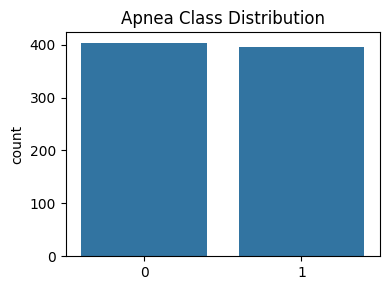

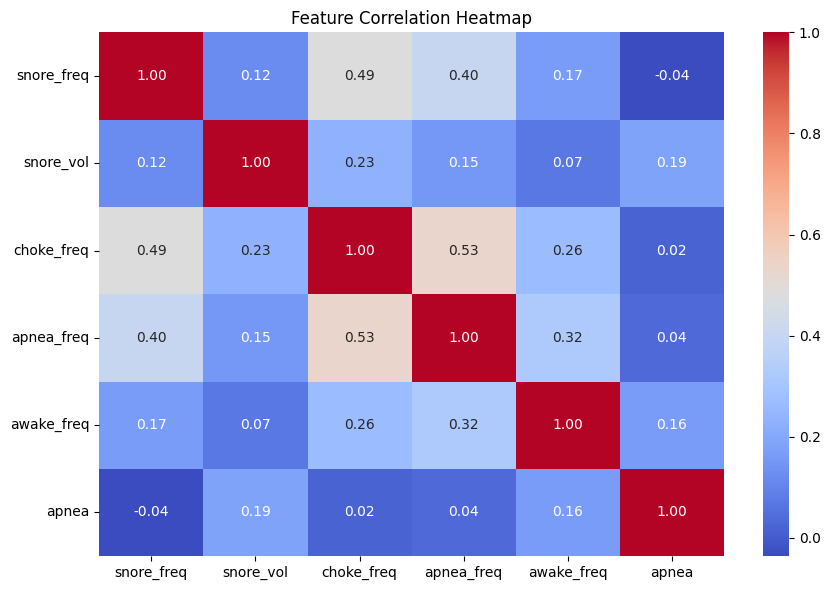

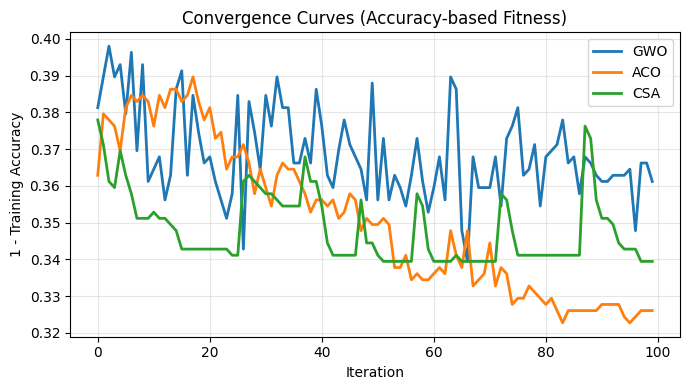

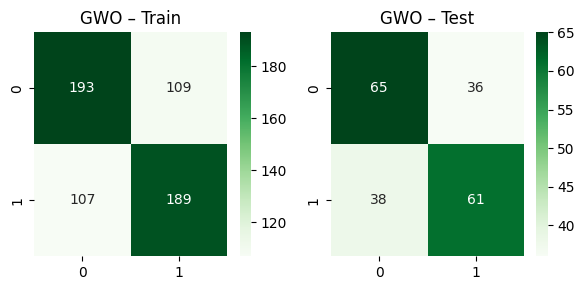

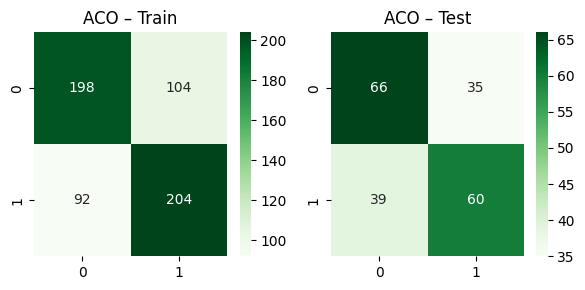

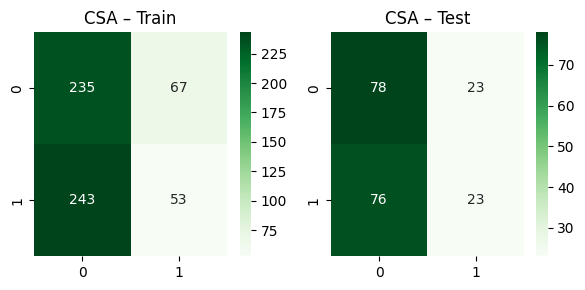

=== Training Metrics ===
                GWO       ACO       CSA
Accuracy   0.638796  0.672241  0.481605
Precision  0.634228  0.662338  0.441667
Recall     0.638514  0.689189  0.179054
F1-score   0.636364  0.675497  0.254808

=== Testing Metrics ===
                GWO       ACO       CSA
Accuracy   0.630000  0.630000  0.505000
Precision  0.628866  0.631579  0.500000
Recall     0.616162  0.606061  0.232323
F1-score   0.622449  0.618557  0.317241


In [2]:
# ==========================================================
# 1. IMPORT LIBRARIES
# ==========================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score
)

np.random.seed(42)

# ==========================================================
# 2. USER-TUNABLE PARAMETERS
# ==========================================================
N_HIDDEN = 50
POP_SIZE = 100
ITERATIONS = 100

# ==========================================================
# 3. LOAD & PREPROCESS DATA
# ==========================================================
df = pd.read_csv("sleep_disordered_breathing.csv")

# Features and label
X = df.drop(columns=["apnea"]).values
y = df["apnea"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.25, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==========================================================
# 4. DATA VISUALIZATION
# ==========================================================
plt.figure(figsize=(4,3))
sns.countplot(x=y)
plt.title("Apnea Class Distribution")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9,6))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

# ==========================================================
# 5. ANN MODEL & FITNESS (Accuracy-based)
# ==========================================================
def ann_forward(X, weights):
    w1, b1, w2, b2 = weights
    a1 = np.tanh(X @ w1 + b1)
    z2 = a1 @ w2 + b2
    z2 = np.clip(z2, -20, 20)
    return 1 / (1 + np.exp(-z2))

def decode_weights(vec, n_in, n_h):
    idx = 0
    w1 = vec[idx:idx+n_in*n_h].reshape(n_in, n_h)
    idx += n_in*n_h
    b1 = vec[idx:idx+n_h]
    idx += n_h
    w2 = vec[idx:idx+n_h].reshape(n_h,1)
    idx += n_h
    b2 = vec[idx]
    return w1, b1, w2, b2

DIM = X_train.shape[1]*N_HIDDEN + N_HIDDEN + N_HIDDEN + 1

def fitness(pop):
    """Fitness = 1 - training accuracy (to minimize)."""
    f = np.zeros(len(pop))
    for i, ind in enumerate(pop):
        w = decode_weights(ind, X_train.shape[1], N_HIDDEN)
        y_hat = ann_forward(X_train, w).flatten()
        y_pred = (y_hat > 0.5).astype(int)
        f[i] = 1 - accuracy_score(y_train, y_pred)
    return f

# ==========================================================
# 6. OPTIMIZERS
# ==========================================================
def GWO():
    wolves = np.random.uniform(-1, 1, (POP_SIZE, DIM))
    history = []

    for t in range(ITERATIONS):
        fit = fitness(wolves)
        history.append(float(np.min(fit)))

        idx = np.argsort(fit)
        alpha, beta, delta = wolves[idx[:3]]

        a = 2 - 2 * (t / ITERATIONS)
        for i in range(POP_SIZE):
            for leader in (alpha, beta, delta):
                A = 2 * a * np.random.rand(DIM) - a
                C = 2 * np.random.rand(DIM)
                wolves[i] -= A * np.abs(C * leader - wolves[i]) / 3

    return wolves[np.argmin(fitness(wolves))], history

def ACO():
    ants = np.random.uniform(-1, 1, (POP_SIZE, DIM))
    history = []

    for _ in range(ITERATIONS):
        fit = fitness(ants)
        history.append(float(np.min(fit)))
        best = ants[np.argmin(fit)]
        ants += 0.1 * np.random.randn(*ants.shape) + 0.05 * best

    return best, history

def CSA():
    crows = np.random.uniform(-1, 1, (POP_SIZE, DIM))
    memory = crows.copy()
    history = []

    for _ in range(ITERATIONS):
        fit = fitness(crows)
        history.append(float(np.min(fit)))
        best = crows[np.argmin(fit)]

        for i in range(POP_SIZE):
            if np.random.rand() < 0.8:
                crows[i] += np.random.rand() * (best - memory[i])
            else:
                crows[i] = np.random.uniform(-1, 1, DIM)

        memory = crows.copy()

    return best, history

# ==========================================================
# 7. TRAIN MODELS
# ==========================================================
best_gwo, hist_gwo = GWO()
best_aco, hist_aco = ACO()
best_csa, hist_csa = CSA()

# ==========================================================
# 8. CONVERGENCE CURVES
# ==========================================================
plt.figure(figsize=(7,4))
plt.plot(hist_gwo, label="GWO", linewidth=2)
plt.plot(hist_aco, label="ACO", linewidth=2)
plt.plot(hist_csa, label="CSA", linewidth=2)
plt.xlabel("Iteration")
plt.ylabel("1 - Training Accuracy")
plt.title("Convergence Curves (Accuracy-based Fitness)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ==========================================================
# 9. EVALUATION + CONFUSION MATRICES
# ==========================================================
def evaluate_and_plot(best, name):
    w = decode_weights(best, X_train.shape[1], N_HIDDEN)

    ytr_prob = ann_forward(X_train, w).flatten()
    yte_prob = ann_forward(X_test, w).flatten()

    ytr_pred = (ytr_prob > 0.5).astype(int)
    yte_pred = (yte_prob > 0.5).astype(int)

    # Plot confusion matrices
    fig, ax = plt.subplots(1, 2, figsize=(6,3))
    sns.heatmap(confusion_matrix(y_train, ytr_pred),
                annot=True, fmt="d", cmap="Greens", ax=ax[0])
    sns.heatmap(confusion_matrix(y_test, yte_pred),
                annot=True, fmt="d", cmap="Greens", ax=ax[1])
    ax[0].set_title(f"{name} – Train")
    ax[1].set_title(f"{name} – Test")
    plt.tight_layout()
    plt.show()

    return ytr_pred, yte_pred

preds = {
    "GWO": evaluate_and_plot(best_gwo, "GWO"),
    "ACO": evaluate_and_plot(best_aco, "ACO"),
    "CSA": evaluate_and_plot(best_csa, "CSA")
}

# ==========================================================
# 10. VERTICAL RESULTS TABLE (TRAIN + TEST)
# ==========================================================
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
table_train = {}
table_test = {}

for algo, (ytrp, ytep) in preds.items():
    table_train[algo] = [
        accuracy_score(y_train, ytrp),
        precision_score(y_train, ytrp),
        recall_score(y_train, ytrp),
        f1_score(y_train, ytrp)
    ]
    table_test[algo] = [
        accuracy_score(y_test, ytep),
        precision_score(y_test, ytep),
        recall_score(y_test, ytep),
        f1_score(y_test, ytep)
    ]

df_train = pd.DataFrame(table_train, index=metrics)
df_test = pd.DataFrame(table_test, index=metrics)

print("=== Training Metrics ===")
print(df_train)
print("\n=== Testing Metrics ===")
print(df_test)

# Save to CSV
df_train.to_csv("Train_ANN_Metaheuristic_Results.csv")
df_test.to_csv("Test_ANN_Metaheuristic_Results.csv")
